### Рубежный контроль №2 ТМО Перевощиков Никита ИУ5Ц-84Б

# Датасет "Forbes Billionaires of 2021"

## Описание датасета
Мы проводим исследование фиктивного датасета для разведочного анализа данных (EDA) и тестирования простых моделей прогнозирования. Датасет содержит 2755 строк и 7 столбцов.

Ссылка на датасет [Forbes Billionaires of 2021]: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## Цель РК№2
Постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей использовать методы 1 и 2. Оценить качество моделей на основе подходящих метрик качества (не менее двух метрик).

## Описание колонок
1. **Name:** Имена миллиардеров.
2. **NetWorth:** Их чистый капитал в миллиардах (USD $).
3. **Country:** Название страны, в которой они основаны.
4. **Source:** Источник их дохода.
5. **Rank:** Глобальные позиции в сравнении с их чистым капиталом.
6. **Age:** Возраст всех миллиардеров в списке.
7. **Industry:** сектор / отрасль / сегмент рынка, над которым работают все миллиардеры.

## План по выполнению РК№2
1. Загрузить данные и изучить их.
2. Заполнить пропущенные значения и обработать аномалии.
3. Построить модели классификации или регрессии с использованием двух методов.
4. Оценить качество моделей на основе подходящих метрик качества.

## Подключение библиотеки и импорт данных

In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt
from IPython.display import Image
from io import StringIO
import graphviz
import pydotplus
from sklearn.model_selection import train_test_split
%matplotlib inline
sb.set(style="ticks")
from IPython.display import set_matplotlib_formats
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import timeit

## Загрузка данных

In [2]:
# Загрузка датасета
try:
    df = pd.read_csv('Billionaire.csv', delimiter=',')
    print('Загружен датасет')
except Exception as ex:
    print('Отсутствует датасет. Проверьте путь файла')
    print('Error:', ex)

Загружен датасет


# Анализ данных

## Изучение данных

In [3]:
# Выводим информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2755 entries, 0 to 2754
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      2755 non-null   object 
 1   NetWorth  2755 non-null   object 
 2   Country   2755 non-null   object 
 3   Source    2755 non-null   object 
 4   Rank      2755 non-null   int64  
 5   Age       2676 non-null   float64
 6   Industry  2755 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 150.8+ KB


In [4]:
# Привести названия всех колонок к нижнему регистру
df.columns = df.columns.str.lower()

In [5]:
# Первые 5 строк
df.head()

,name,networth,country,source,rank,age,industry
0,Jeff Bezos,$177 B,United States,Amazon,1,57.0,Technology
1,Elon Musk,$151 B,United States,"Tesla, SpaceX",2,49.0,Automotive
2,Bernard Arnault & family,$150 B,France,LVMH,3,72.0,Fashion & Retail
3,Bill Gates,$124 B,United States,Microsoft,4,65.0,Technology
4,Mark Zuckerberg,$97 B,United States,Facebook,5,36.0,Technology


In [6]:
# Последние 5 строк
df.tail()

,name,networth,country,source,rank,age,industry
2750,Daniel Yong Zhang,$1 B,China,e-commerce,2674,49.0,Technology
2751,Zhang Yuqiang,$1 B,China,Fiberglass,2674,65.0,Manufacturing
2752,Zhao Meiguang,$1 B,China,gold mining,2674,58.0,Metals & Mining
2753,Zhong Naixiong,$1 B,China,conglomerate,2674,58.0,Diversified
2754,Zhou Wei family,$1 B,China,Software,2674,54.0,Technology


In [7]:
df.describe()

,rank,age
count,2755.000000,2676.000000
mean,1345.663521,63.113602
std,772.669811,13.445153
min,1.000000,18.000000
25%,680.000000,54.000000
50%,1362.000000,63.000000
75%,2035.000000,73.000000
max,2674.000000,99.000000


##### Анализ описательной статистики
- **rank:** Среднее значение равно примерно 1346, что указывает на среднее положение в рейтинге.
- **age:** Средний возраст составляет около 63 лет.


## Анализ выбросов (Ящик с усами)

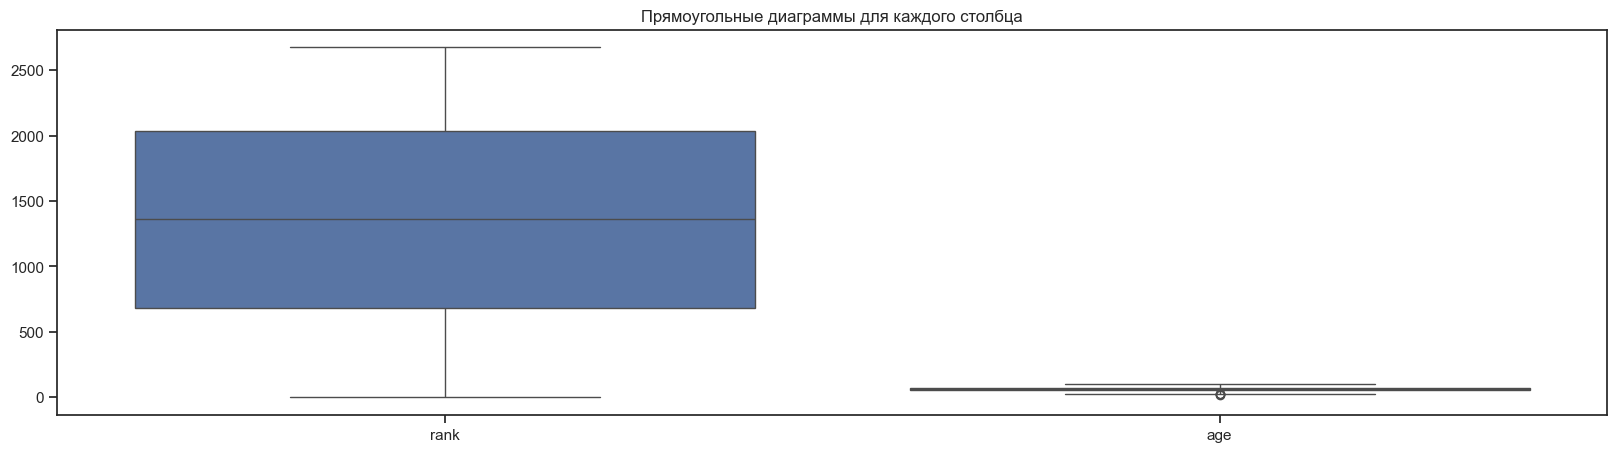

In [8]:
plt.figure(figsize=(20, 5))
sb.boxplot(data=df)
plt.title("Прямоугольные диаграммы для каждого столбца")
plt.show()

Выбросы имеются у колонки age. Рассмотрим диаграмму для столбца 'age'.

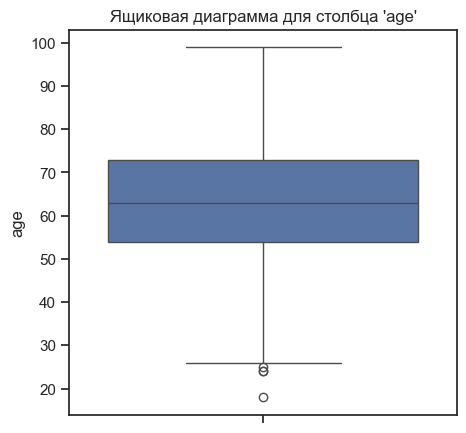

In [9]:
plt.figure(figsize=(5, 5))
sb.boxplot(data=df['age'])
plt.title("Ящиковая диаграмма для столбца 'age'")
plt.show()

Выбросы имеются у колонки age

In [10]:
# Скорпируем
df_data = df.copy()

In [11]:
# Очистим
df_data = df_data[df_data['age'] > (df_data.describe()['age']['25%'] - df_data.describe()['age']['std'])]
df_data = df_data[df_data['age'] < (df_data.describe()['age']['75%'] + df_data.describe()['age']['std'])]

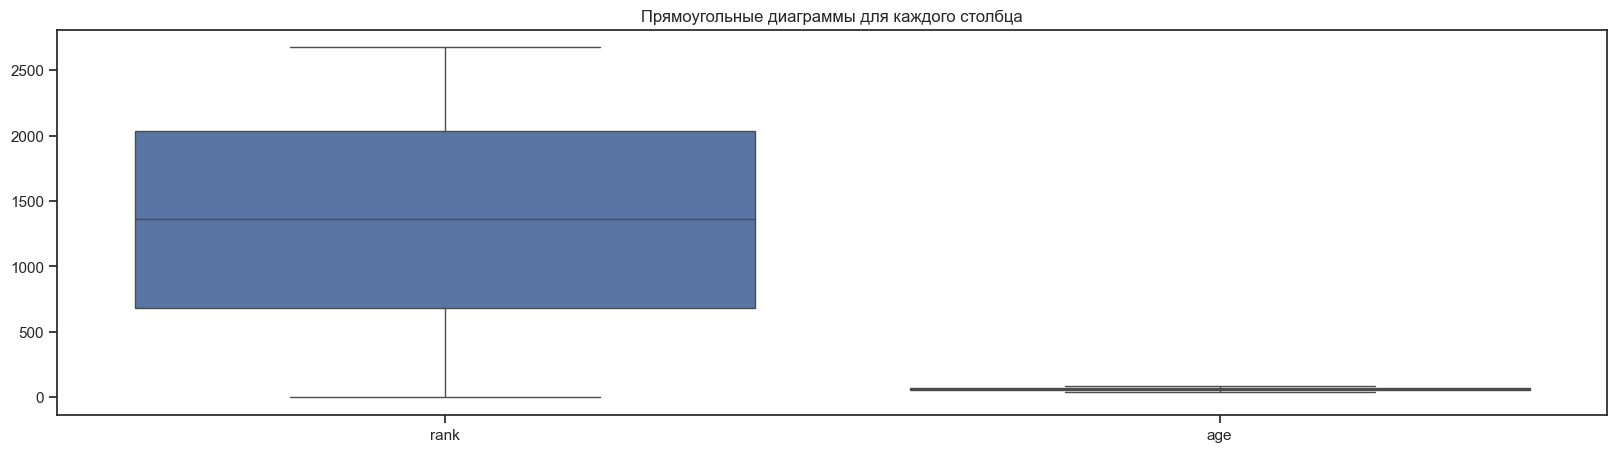

In [12]:
plt.figure(figsize=(20, 5))
sb.boxplot(data=df_data)
plt.title("Прямоугольные диаграммы для каждого столбца")
plt.show()

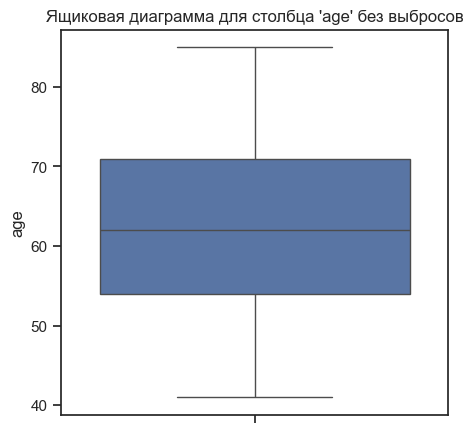

In [13]:
plt.figure(figsize=(5, 5))
sb.boxplot(data=df_data['age'])
plt.title("Ящиковая диаграмма для столбца 'age' без выбросов")
plt.show()

Результат представляет собой нормальную диаграмму без выбросов.

## Пропуски

In [14]:
df_data.isna().sum()

name        0
networth    0
country     0
source      0
rank        0
age         0
industry    0
dtype: int64

В наборе нет пропусков, следовательно не нужно их обрабатывать.

## Дубликаты

In [15]:
# Подсчитаем количество дублирующих строк
duplicate_count = df_data.duplicated().sum()
print("Количество дублирующихся строк:", duplicate_count)

Количество дублирующихся строк: 0


В наборе нет дублирующих значений, следовательно не нужно их обрабатывать.

## Обработка категориальных признаков

In [16]:
pd.set_option("display.width", 70)

Нет категориальных значений, значит ненужно кодировать категориальных признаков.

## Масштабирование данных

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Создаем объект MinMaxScaler
scl = MinMaxScaler()

# Выбираем только числовые признаки для масштабирования
numeric_columns = df_data.select_dtypes(include=['float64', 'int64']).columns

# Масштабируем числовые признаки
data_scaled = df_data.copy()
data_scaled[numeric_columns] = scl.fit_transform(df_data[numeric_columns])

# Выводим результат
data_scaled

,name,networth,country,source,rank,age,industry
0,Jeff Bezos,$177 B,United States,Amazon,0.000000,0.363636,Technology
1,Elon Musk,$151 B,United States,"Tesla, SpaceX",0.000374,0.181818,Automotive
2,Bernard Arnault & family,$150 B,France,LVMH,0.000748,0.704545,Fashion & Retail
3,Bill Gates,$124 B,United States,Microsoft,0.001122,0.545455,Technology
6,Larry Ellison,$93 B,United States,software,0.002245,0.795455,Technology
...,...,...,...,...,...,...,...
2750,Daniel Yong Zhang,$1 B,China,e-commerce,1.000000,0.181818,Technology
2751,Zhang Yuqiang,$1 B,China,Fiberglass,1.000000,0.545455,Manufacturing
2752,Zhao Meiguang,$1 B,China,gold mining,1.000000,0.386364,Metals & Mining
2753,Zhong Naixiong,$1 B,China,conglomerate,1.000000,0.386364,Diversified


## Обучение и тестирование

In [18]:
# Преобразование столбца "NetWorth" в числовой формат
df_data['networth'] = df_data['networth'].str.replace('$', '').str.replace('B', '').astype(float)

In [19]:
# Подготовка данных
x = df_data.drop(['networth', 'name', 'country', 'source', 'industry'], axis=1)
y = df_data['networth']

### Деление на обучающую и тестовую выборки

In [20]:
# Разделение данных на обучающую и тестовую выборки
x_train,  x_test,  y_train,  y_test = train_test_split(x,  y, test_size=0.2, random_state=42)

### Метод 1: Линейная регрессия

In [21]:
# Устанавливаем нужные параметры
parameters = {}

# Инициализируем модель
model = GridSearchCV(LinearRegression(), param_grid=parameters, scoring='neg_root_mean_squared_error')

In [22]:
%%time

# Обучим модель на обучающей выборке
model.fit(x_train, y_train)

# Узнаем RMSE обучающей выборки
RMSE_TRAIN = -model.best_score_
print('RMSE TRAIN:', RMSE_TRAIN)
print('TIME TRAIN [s]:', round(model.refit_time_, 3))

RMSE TRAIN: 9.25362027091582
TIME TRAIN [s]: 0.001
CPU times: total: 15.6 ms
Wall time: 42 ms


**Проверка на тестовой выборки**

In [23]:
%%time
start_time = timeit.default_timer()
# Получим предсказания на тестовой выборке
predictions = model.predict(x_test)

# Узнаем RMSE на тестовой выборке
RMSE_TEST = mean_squared_error(y_test, predictions, squared=False)
print('RMSE TEST:', RMSE_TEST)
print('Предсказание:', predictions.mean())

RMSE TEST: 4.498156821315772
Предсказание: 4.847756595716353
CPU times: total: 0 ns
Wall time: 7 ms


C:\Users\nikis\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [24]:
count_model = 0  # Инициализируем переменную count_model
# Зафиксируем результаты
parameters[count_model] = pd.Series({
    'NAME': 'LinearRegression', 
    'RMSE TRAIN': RMSE_TRAIN, 
    'RMSE TEST': RMSE_TEST, 
    'PREDICTIONS': predictions, 
    'TIME TRAINING [s]': model.refit_time_, 
    'PARAMETRS': model.best_params_
})

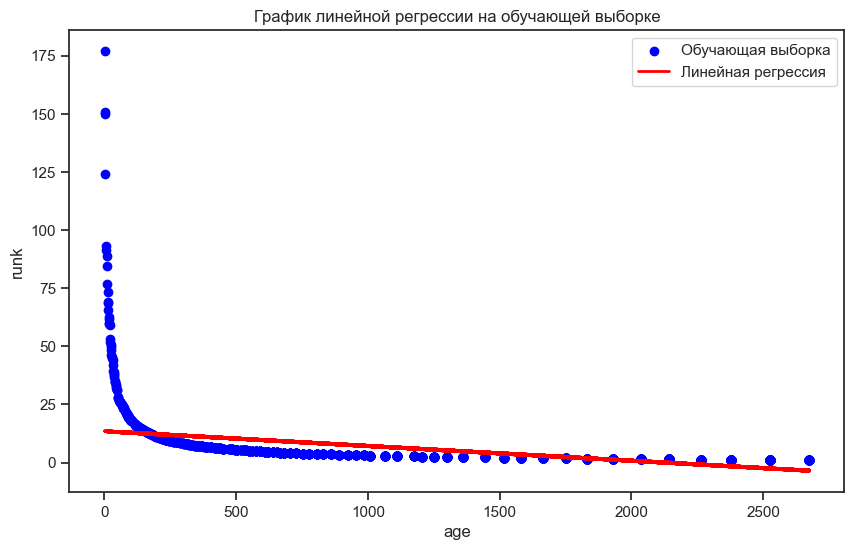

In [25]:
# Построение графика для обучающей выборки
plt.figure(figsize=(10, 6))
plt.scatter(x_train.iloc[:, 0], y_train, color='blue', label='Обучающая выборка')
plt.plot(x_train.iloc[:, 0], model.predict(x_train), color='red', linewidth=2, label='Линейная регрессия')
plt.xlabel('age') 
plt.ylabel('runk') 
plt.title('График линейной регрессии на обучающей выборке')  
plt.legend() 
plt.show() 

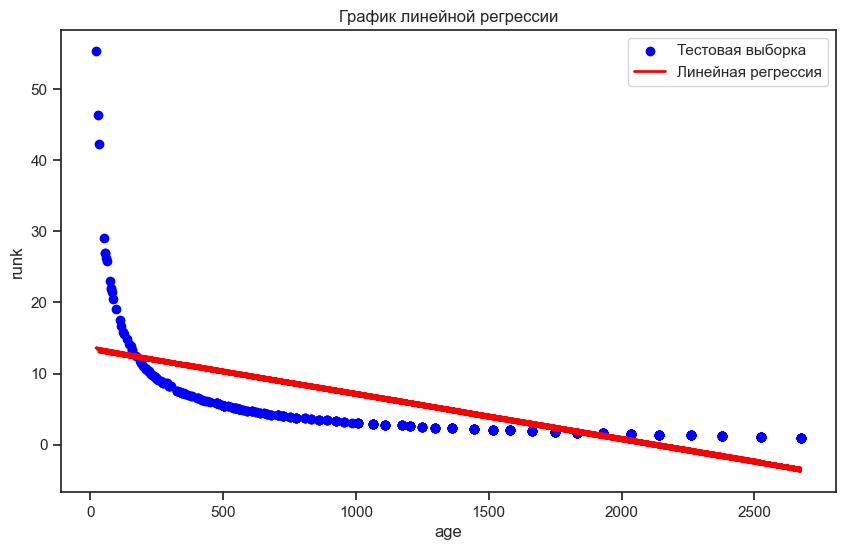

In [26]:
# Построение графика для тестовой выборки
plt.figure(figsize=(10, 6))
plt.scatter(x_test.iloc[:, 0], y_test, color='blue', label='Тестовая выборка')
plt.plot(x_test.iloc[:, 0], predictions, color='red', linewidth=2, label='Линейная регрессия')
plt.xlabel('age')
plt.ylabel('runk')
plt.title('График линейной регрессии')
plt.legend()
plt.show()

In [27]:
# Обучение модели линейной регрессии на обучающих данных (x_train, y_train) и использование обученную модель 
# для предсказания значений целевой переменной на тестовых данных (x_test).
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)
y_pred_linear_reg = linear_reg.predict(x_test)

In [28]:
# Обчуение модели линейной регрессии на данных x и целевой переменной y.
reg1 = LinearRegression().fit(x, y)

In [29]:
# Для получения прогнозов (y_pred_1) с использованием обученной модели reg1 на тестовых данных x_test.
y_pred_1 = reg1.predict(x_test)

In [30]:
print("Средняя абсолютная погрешность:", mean_absolute_error(y_test, y_pred_1))
print("Среднеквадратичная ошибка:", mean_squared_error(y_test, y_pred_1))

Средняя абсолютная погрешность: 2.9367551895001625
Среднеквадратичная ошибка: 19.305155612184674


### Метод 2: Градиентный бустинг

In [31]:
# Метод 2: Градиентный бустинг
gradient_boosting = GradientBoostingRegressor()
gradient_boosting.fit(x_train, y_train)
y_pred_gradient_boosting = gradient_boosting.predict(x_test)

In [32]:
# Создание объекта AdaBoostRegressor с 4 базовыми моделями (n_estimators=4) и случайным начальным состоянием 42 (random_state=42), 
# а затем обучает эту модель на данных x и y.
ab1 = AdaBoostRegressor(n_estimators=4, random_state=42)
ab1.fit(x, y)

AdaBoostRegressor(n_estimators=4, random_state=42)

In [33]:
# Визуализация дерева
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

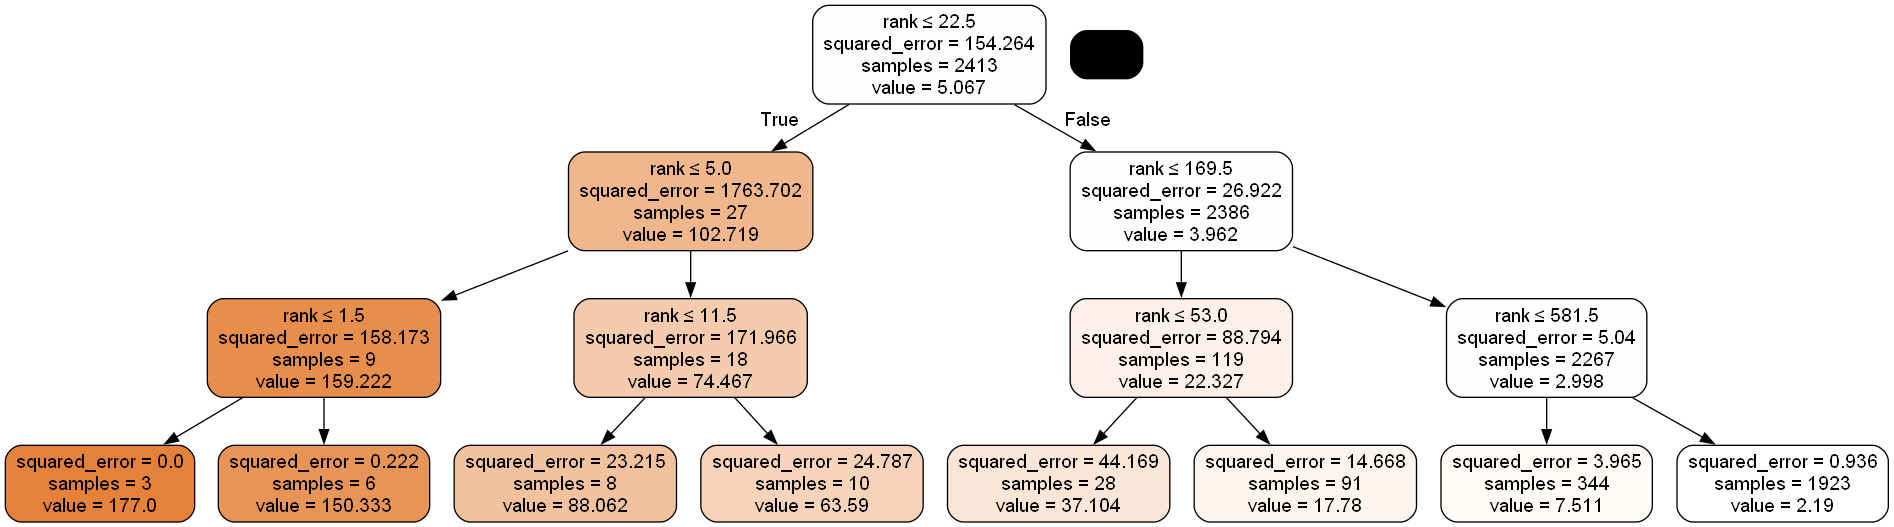

In [34]:
# Создание изображение структуры первого дерева решений, обученного внутри модели AdaBoostRegressor.
Image(get_png_tree(ab1.estimators_[0], x.columns), width="500")

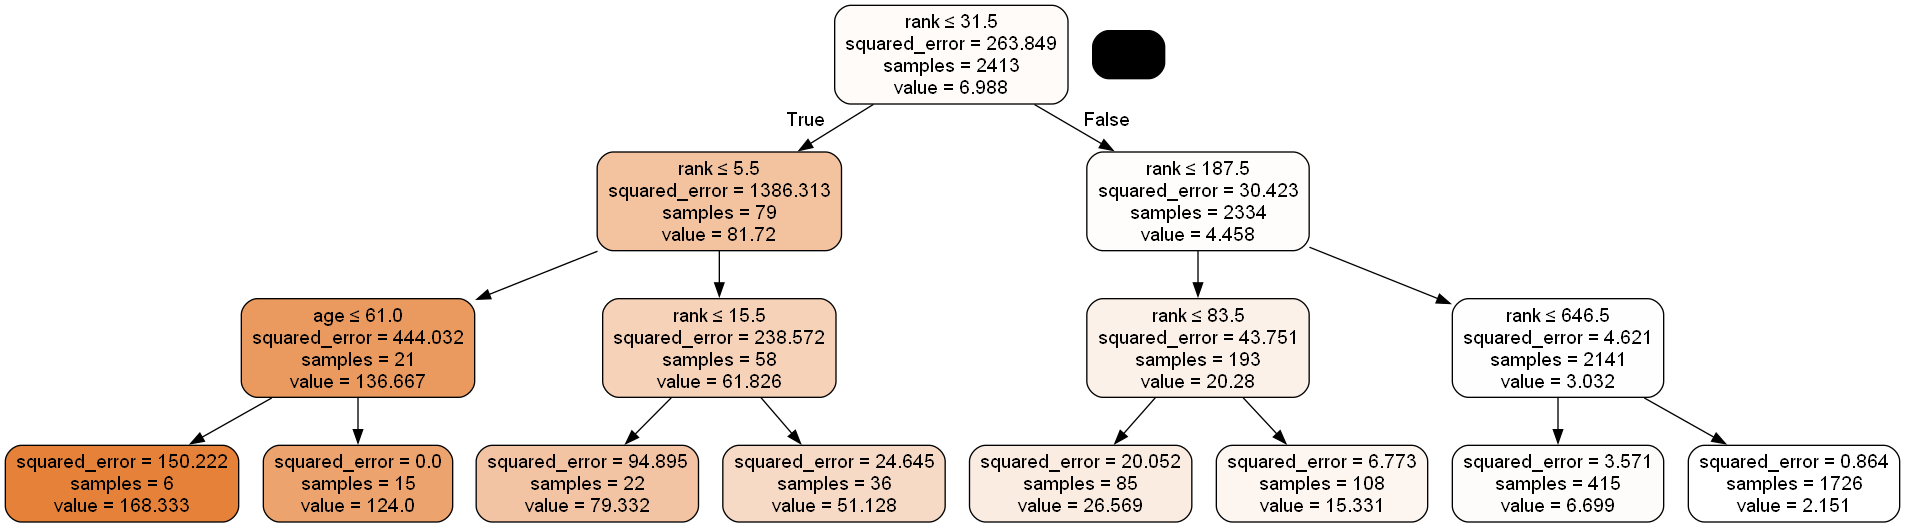

In [35]:
# Создание изображение структуры второго дерева решений, обученного внутри модели AdaBoostRegressor.
Image(get_png_tree(ab1.estimators_[1], x.columns), width="500")

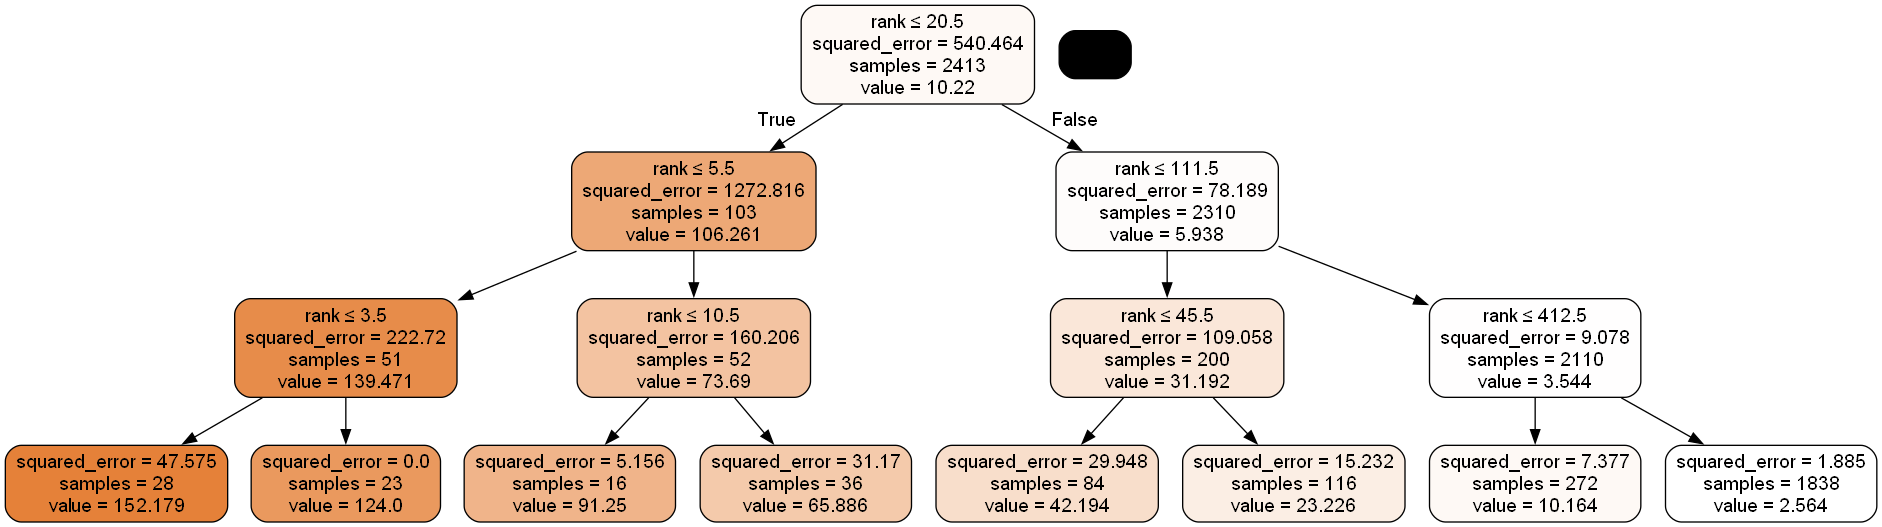

In [36]:
# Создание изображение структуры третьего дерева решений, обученного внутри модели AdaBoostRegressor.
Image(get_png_tree(ab1.estimators_[2], x.columns), width="500")

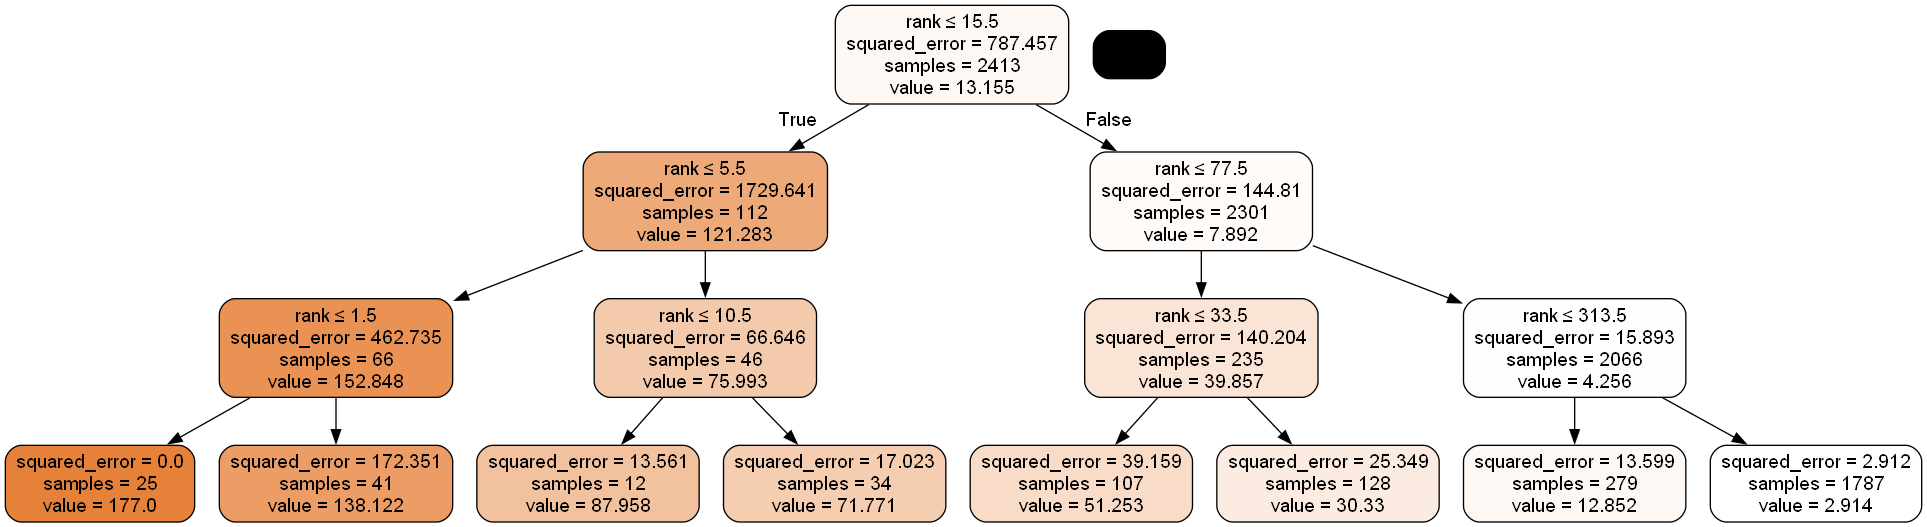

In [37]:
# Создание изображение структуры четвертого дерева решений, обученного внутри модели AdaBoostRegressor.
Image(get_png_tree(ab1.estimators_[3], x.columns), width="500")

In [38]:
# Создание и обучение модели регрессора AdaBoost с 4 базовыми моделями и предсказывает значения на тестовом наборе данных.
regressor = AdaBoostRegressor(n_estimators=4, random_state=42)
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_test)

In [39]:
print('Средняя абсолютная погрешность:', mean_absolute_error(y_test, y_pred))
print('Среднеквадратичная ошибка:', mean_squared_error(y_test, y_pred))

Средняя абсолютная погрешность: 0.970965386587281
Среднеквадратичная ошибка: 1.4722377600605119


### Оценка качества моделей

In [40]:
# Оценка качества моделей
mse_linear_reg = mean_squared_error(y_test, y_pred_linear_reg)
mse_gradient_boosting = mean_squared_error(y_test, y_pred_gradient_boosting)

print("Метод 1: Линейная регрессия")
print(f"MSE: {mse_linear_reg}")

print("\nМетод 2: Градиентный бустинг")
print(f"MSE: {mse_gradient_boosting}")

Метод 1: Линейная регрессия
MSE: 20.23341478914961

Метод 2: Градиентный бустинг
MSE: 0.04117584280965607


### Вывод

MSE для Градиентный бустинг значительно ниже, чем для Линейная регрессия, что указывает на то, что модель градиентного бустинга лучше подходит для данной задачи прогнозирования.

Линейная регрессия имеет более высокую ошибку, что может означать, что зависимость между предикторами и целевой переменной нелинейна, и применение более сложных моделей, таких как градиентный бустинг, может улучшить качество прогнозирования.
Градиентный бустинг вероятно лучше захватывает сложные нелинейные взаимосвязи между признаками и целевой переменной, что приводит к более точным прогнозам.

Таким образом, при выборе модели для данной задачи предпочтительнее использовать метод градиентного бустинга из-за его более низкой среднеквадратичной ошибки.